# Polish IT job market — technology trends & salaries

**Question → analysis → conclusion.** This notebook explores a sample of Polish IT job
offers collected from [theprotocol.it](https://theprotocol.it): which technologies are
in demand, what they pay, and how Wrocław compares to remote work.

**Data & ethics:** a bounded, spread sample collected respectfully (robots.txt, no
personal data, attribution). B2B (net) and employment (gross) salaries are kept separate.
See `docs/research/data-sources.md`.

In [1]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from it_job_radar import config, db, analyze

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

conn = db.connect()
n_offers = len(db.read_table(conn, "offers"))
n_salaried = db.read_table(conn, "offer_salaries")["monthly_from"].notna().sum()
print(f"Offers in snapshot: {n_offers}  |  with a salary range: {n_salaried}")

Offers in snapshot: 314  |  with a salary range: 103


## Q1 — Which technologies are most in demand?

We count how many offers mention each (normalized) technology, overall and for junior
roles specifically.

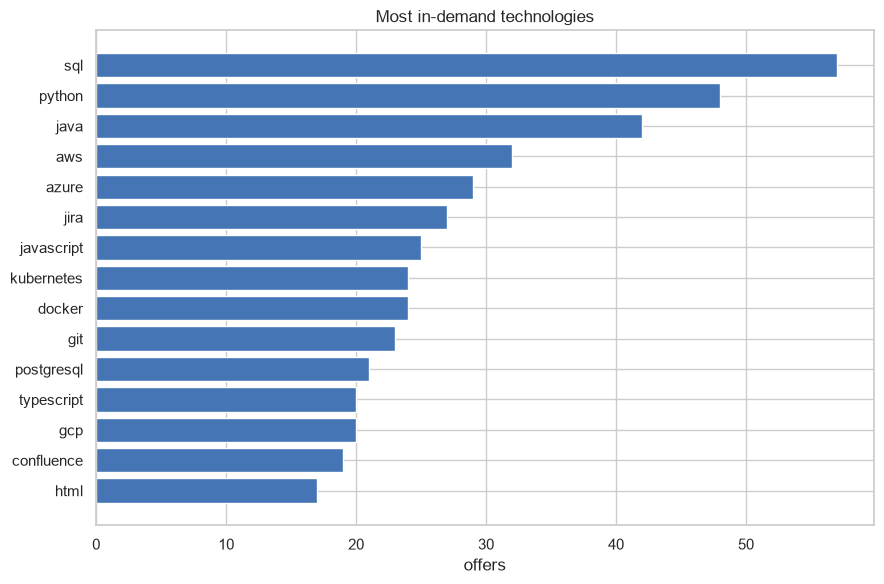

Top technologies for JUNIOR roles:
      technology  offers
active directory       4
            jira       3
  windows server       2
         windows       2
          python       2
microsoft office       2
      confluence       2
             xdr       1
  wi-fi networks       1
    wi-fi access       1


In [2]:
top = analyze.top_technologies(conn, limit=15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["technology"][::-1], top["offers"][::-1], color="#4575b4")
ax.set(title="Most in-demand technologies", xlabel="offers")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "fig1_top_tech.png", dpi=110)
plt.show()

top_junior = analyze.top_technologies(conn, seniority="junior", limit=10)
print("Top technologies for JUNIOR roles:")
print(top_junior.to_string(index=False))

**Conclusion (Q1):** the market is dominated by a general-purpose data/back-end stack
(Python, SQL, cloud) with the usual tooling (git, Docker, Kubernetes). Junior demand
tracks the same core, which is exactly what a candidate should learn first.

## Q2 — What do they pay? (by seniority, B2B vs employment)

Median monthly salary per seniority. B2B (net + VAT) and employment (gross) are shown
**separately** — pooling them would be meaningless. Hourly B2B rates are scaled to a
monthly figure.

B2B (net, PLN/month):
seniority  offers  median_from  median_to
   junior       3       8000.0    13000.0
      mid      27      12800.0    17920.0
   senior      40      21825.0    27000.0
   expert       3      19320.0    28560.0
     lead       3      18000.0    25000.0
  manager       2      18050.0    22465.0

Employment (gross, PLN/month):
seniority  offers  median_from  median_to
   intern       1       5280.0     6240.0
   junior       2       7000.0    10500.0
      mid      26       7800.0    13000.0
   senior      13      11000.0    14500.0
   expert       3      15000.0    22000.0
     lead       6      18750.0    21950.0
  manager       2      13690.0    17065.0


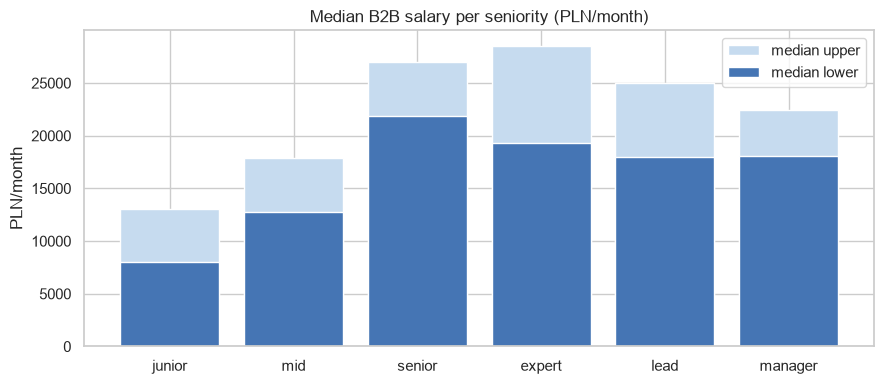

In [3]:
b2b = analyze.salary_by_seniority(conn, kind=config.CONTRACT_B2B)
uop = analyze.salary_by_seniority(conn, kind=config.CONTRACT_EMPLOYMENT)
print("B2B (net, PLN/month):");  print(b2b.to_string(index=False))
print("\nEmployment (gross, PLN/month):");  print(uop.to_string(index=False))

if not b2b.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    x = range(len(b2b))
    ax.bar(x, b2b["median_to"], color="#c6dbef", label="median upper")
    ax.bar(x, b2b["median_from"], color="#4575b4", label="median lower")
    ax.set_xticks(list(x)); ax.set_xticklabels(b2b["seniority"])
    ax.set(title="Median B2B salary per seniority (PLN/month)", ylabel="PLN/month")
    ax.legend(); fig.tight_layout()
    fig.savefig(config.FIGURES_DIR / "fig2_salary.png", dpi=110)
    plt.show()

**Conclusion (Q2):** pay rises clearly with seniority. The B2B vs employment split
matters — the same role reads very differently depending on contract type, so any
"average IT salary" that mixes them is misleading.

## Q3 — Wrocław vs remote

How many offers, and what median pay, for Wrocław-based roles vs fully remote ones?

In [4]:
compare = analyze.wroclaw_vs_remote(conn, kind=config.CONTRACT_B2B)
print(compare.to_string(index=False))

  group  offers  median_from  median_to
Wrocław       4      14180.0    17700.0
 remote      32      19200.0    24000.0


**Conclusion (Q3):** remote roles broaden the pool well beyond any single city — a
candidate in Wrocław is not limited to local listings. (Medians on small buckets are
indicative, not definitive — see limitations.)

## Q4 — Which work modes dominate?

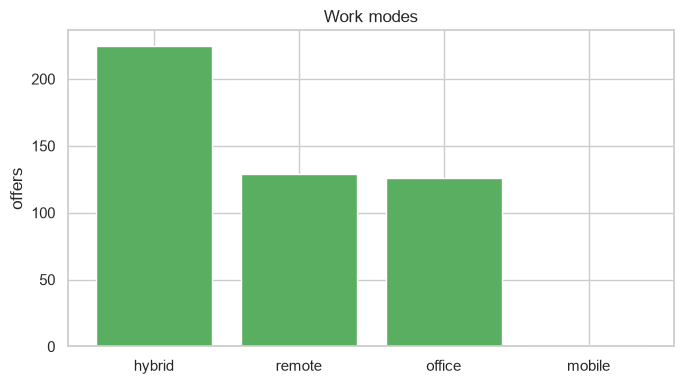

,work_mode,offers
0,hybrid,225
1,remote,129
2,office,126
3,mobile,1


In [5]:
modes = analyze.work_mode_distribution(conn)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(modes["work_mode"], modes["offers"], color="#5aae61")
ax.set(title="Work modes", ylabel="offers")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "fig3_work_modes.png", dpi=110)
plt.show()
modes

**Conclusion (Q4):** hybrid and remote together dominate — fully on-site is the minority,
which matches the post-pandemic Polish IT market.

## Methodology & limitations
- **Bounded, spread sample** (not the whole base) collected respectfully — small buckets
  (e.g. rare seniority levels) have unstable medians.
- **No currency conversion** — salary medians are within PLN; EUR/USD/GBP offers are
  excluded from PLN medians.
- **Unit edge-cases** — hourly B2B rates are scaled by a fixed 160h/month; unusual units
  can skew a single offer.
- **Collection runs locally** — theprotocol serves stripped pages to datacenter IPs, so
  the automated site build uses a local snapshot (documented, not evaded).